In [15]:
import yfinance as yf
import pandas as pd

vix = yf.download(
    "^VIX",
    period="1y",
    auto_adjust=True
)

vix.columns = vix.columns.get_level_values(0)

vix.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-07-31,16.719999,17.170000,14.740000,14.990000,0
2025-08-01,20.379999,21.900000,17.389999,17.400000,0
2025-08-04,17.520000,19.580000,17.480000,19.559999,0
2025-08-05,17.850000,18.940001,17.110001,17.209999,0
2025-08-06,16.770000,17.879999,16.559999,17.219999,0


In [16]:
spy = yf.download(
    "SPY",
    period="1y",
    auto_adjust=True
)

spy.columns = spy.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [17]:
common_dates = spy.index.intersection(vix.index)

spy = spy.loc[common_dates]
vix = vix.loc[common_dates]

In [18]:
spy_returns = spy["Close"].pct_change()

vix_returns = vix["Close"].pct_change()

In [19]:
spy_returns.head()

Date
2025-08-01         NaN
2025-08-04    0.015200
2025-08-05   -0.005070
2025-08-06    0.007660
2025-08-07   -0.000838
Name: Close, dtype: float64

In [20]:
vix_returns.head()

Date
2025-08-01         NaN
2025-08-04   -0.140334
2025-08-05    0.018836
2025-08-06   -0.060504
2025-08-07   -0.011926
Name: Close, dtype: float64

In [21]:
returns = (
    pd.DataFrame({
        "SPY": spy_returns,
        "VIX": vix_returns
    })
    .dropna()
)

In [24]:
correlation = returns["SPY"].corr(returns["VIX"])

print(correlation)

-0.839968706501402


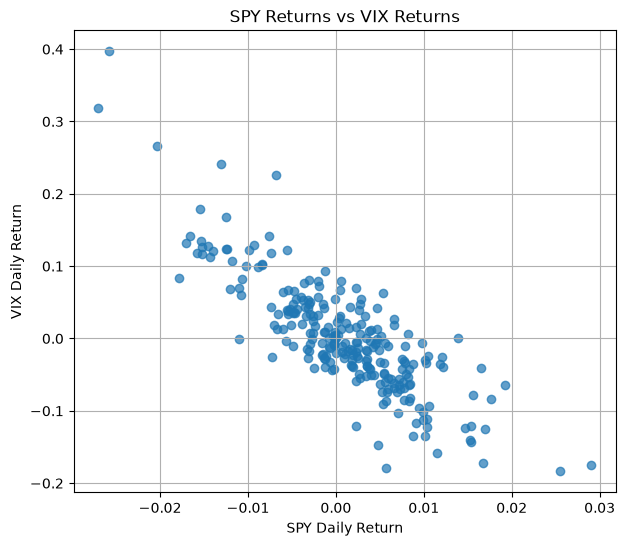

In [25]:
plt.figure(figsize=(7,6))

plt.scatter(
    returns["SPY"],
    returns["VIX"],
    alpha=0.7
)

plt.xlabel("SPY Daily Return")
plt.ylabel("VIX Daily Return")
plt.title("SPY Returns vs VIX Returns")
plt.grid(True)

plt.savefig(
    "../report/SPY_VIX_Scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()